# Week 2 — Exploratory Data Analysis (EDA)
**DSA 4020A Semester Project — PSA Machine Translation**

Scope: this notebook analyzes only the final curated datasets in `data/final_data/`:
- `English_Domain_Dataset.csv` — English sentences + Domain label (monolingual, largest set)
- `English_Swahili_Dataset.csv` — English–Kiswahili parallel pairs
- `English_Ekegusii_Dataset.csv` — English–Ekegusii parallel pairs
- `Trilingual_English_Swahili_Ekegusii_Dataset.csv` — complete 3-way triplets

Covers: domain distribution, text length histograms, vocabulary size, and language-pair statistics.

In [1]:
import os

if "COLAB_GPU" in os.environ or os.environ.get("COLAB_RELEASE_TAG"):
    if not os.path.exists("Multilogual_transaltion_nlp"):
        os.system("git clone https://github.com/aykahsay/Multilogual_transaltion_nlp.git")
    os.chdir("Multilogual_transaltion_nlp")

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = os.path.join("data", "final_data") if os.path.exists("data") else os.path.join("..", "data", "final_data")

domain_df   = pd.read_csv(os.path.join(DATA_DIR, "English_Domain_Dataset.csv"), dtype=str)
sw_df       = pd.read_csv(os.path.join(DATA_DIR, "English_Swahili_Dataset.csv"), dtype=str)
guz_df      = pd.read_csv(os.path.join(DATA_DIR, "English_Ekegusii_Dataset.csv"), dtype=str)
tri_df      = pd.read_csv(os.path.join(DATA_DIR, "Trilingual_English_Swahili_Ekegusii_Dataset.csv"), dtype=str)

datasets = {
    "English_Domain_Dataset": domain_df,
    "English_Swahili_Dataset": sw_df,
    "English_Ekegusii_Dataset": guz_df,
    "Trilingual_Dataset": tri_df,
}

for name, df in datasets.items():
    print(f"{name:28s} shape={df.shape}  columns={list(df.columns)}")

English_Domain_Dataset       shape=(8903, 2)  columns=['English', 'Domain']
English_Swahili_Dataset      shape=(5736, 3)  columns=['English', 'Kiswahili', 'Domain']
English_Ekegusii_Dataset     shape=(4521, 3)  columns=['English', 'Ekegusii', 'Domain']
Trilingual_Dataset           shape=(2783, 4)  columns=['English', 'Kiswahili', 'Ekegusii', 'Domain']


## 1. Domain Distribution
Domain balance across each dataset — flags which languages/splits are most exposed to domain imbalance.

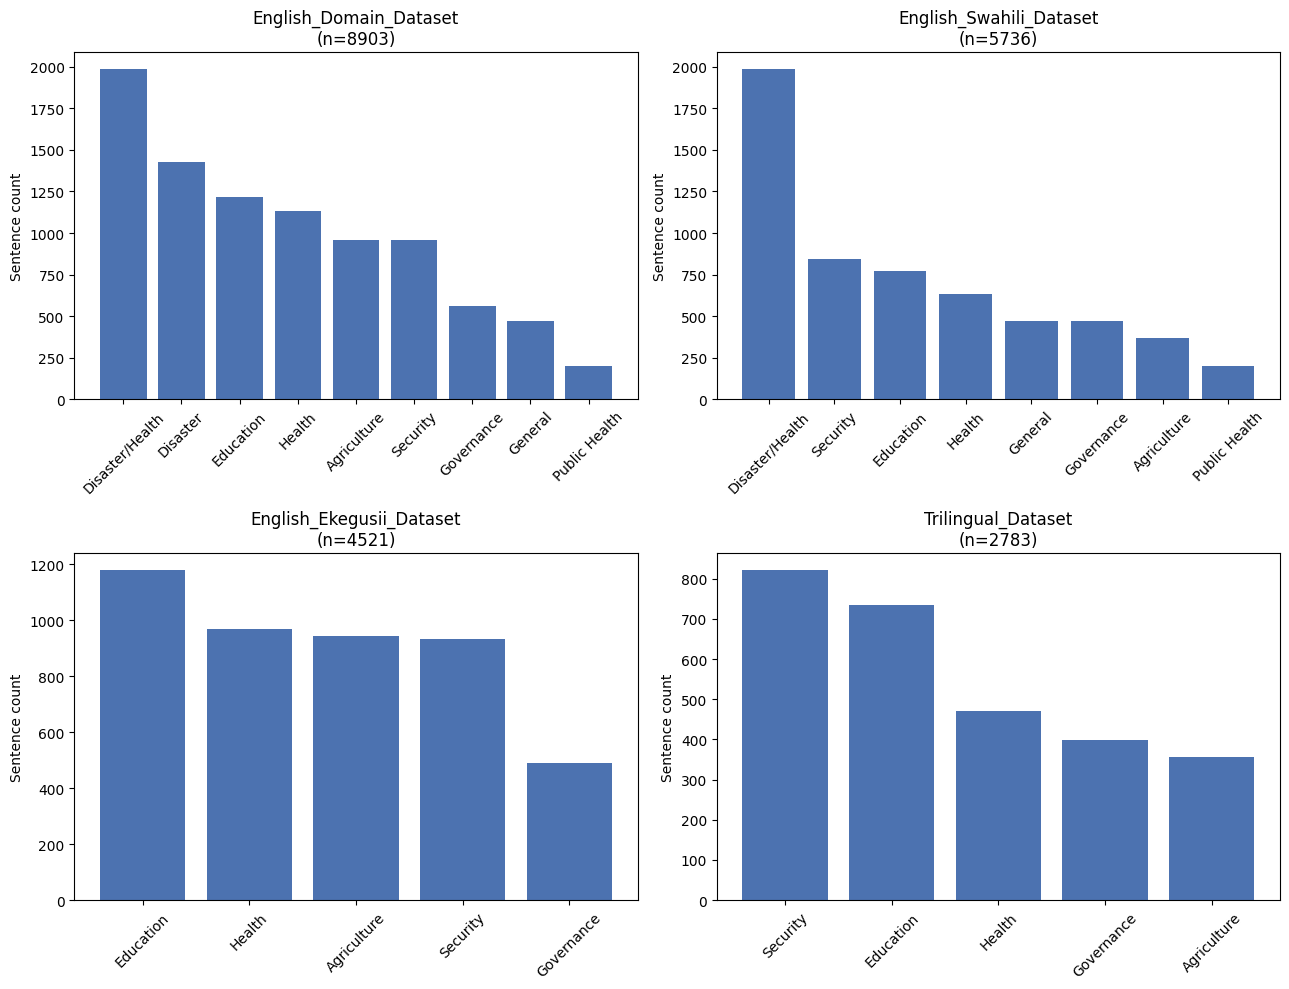

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (name, df) in zip(axes, datasets.items()):
    counts = df["Domain"].value_counts()
    ax.bar(counts.index, counts.values, color="#4C72B0")
    ax.set_title(f"{name}\n(n={len(df)})")
    ax.set_ylabel("Sentence count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("week2_domain_distribution.png", dpi=120)
plt.show()

In [3]:
domain_summary = pd.DataFrame({
    name: df["Domain"].value_counts(normalize=True).round(3) * 100
    for name, df in datasets.items()
}).fillna(0)
domain_summary.columns = [f"{c} (%)" for c in domain_summary.columns]
domain_summary

,English_Domain_Dataset (%),English_Swahili_Dataset (%),English_Ekegusii_Dataset (%),Trilingual_Dataset (%)
Domain,,,,
Agriculture,10.7,6.4,20.9,12.8
Disaster,16.1,0.0,0.0,0.0
Disaster/Health,22.3,34.6,0.0,0.0
Education,13.7,13.4,26.1,26.4
General,5.3,8.2,0.0,0.0
Governance,6.3,8.2,10.8,14.3
Health,12.7,11.0,21.5,16.9
Public Health,2.2,3.5,0.0,0.0
Security,10.7,14.7,20.7,29.5


## 2. Text Length Distributions
Word-count histograms per language, computed from the parallel datasets.

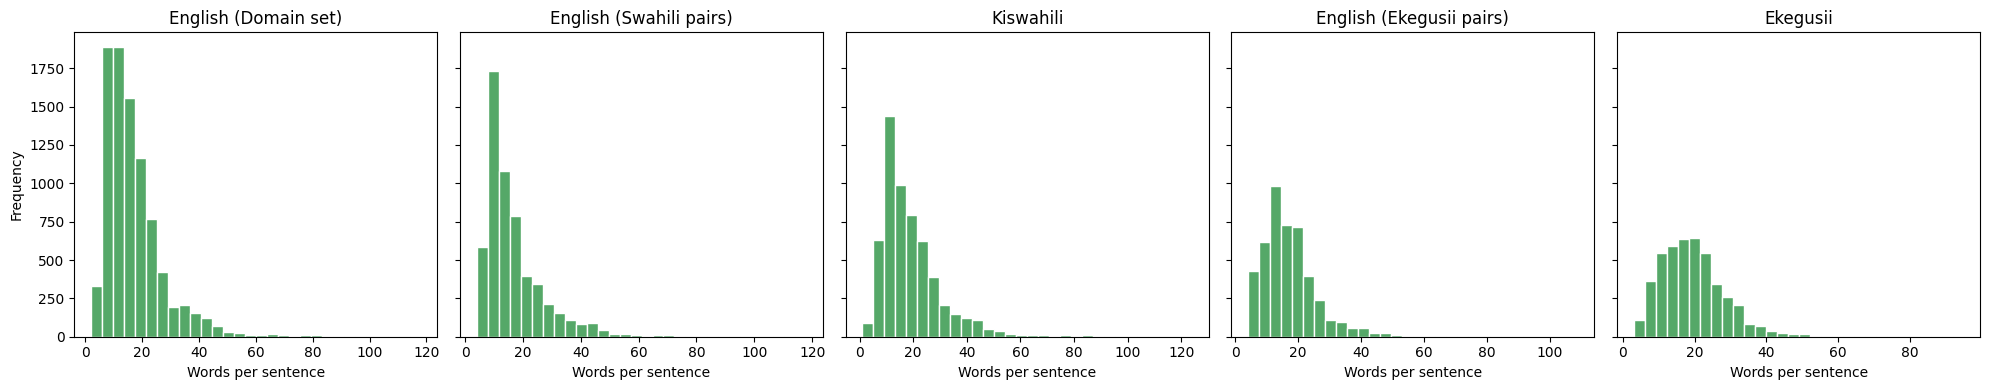

In [4]:
def word_count(series):
    return series.dropna().astype(str).apply(lambda s: len(s.split()))

lengths = {
    "English (Domain set)": word_count(domain_df["English"]),
    "English (Swahili pairs)": word_count(sw_df["English"]),
    "Kiswahili": word_count(sw_df["Kiswahili"]),
    "English (Ekegusii pairs)": word_count(guz_df["English"]),
    "Ekegusii": word_count(guz_df["Ekegusii"]),
}

fig, axes = plt.subplots(1, len(lengths), figsize=(20, 4), sharey=True)
for ax, (name, vals) in zip(axes, lengths.items()):
    ax.hist(vals, bins=30, color="#55A868", edgecolor="white")
    ax.set_title(name)
    ax.set_xlabel("Words per sentence")
axes[0].set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("week2_text_length_histograms.png", dpi=120)
plt.show()

In [5]:
length_stats = pd.DataFrame({
    name: vals.describe()[["count", "mean", "std", "min", "50%", "max"]]
    for name, vals in lengths.items()
}).T
length_stats.rename(columns={"50%": "median"}, inplace=True)
length_stats.round(2)

,count,mean,std,min,median,max
English (Domain set),8903.0,17.00,11.02,2.0,14.0,118.0
English (Swahili pairs),5736.0,16.83,11.74,4.0,13.0,118.0
Kiswahili,5736.0,19.51,12.07,1.0,16.0,124.0
English (Ekegusii pairs),4521.0,17.08,9.43,4.0,15.0,109.0
Ekegusii,4521.0,19.75,9.50,3.0,19.0,95.0


## 3. Vocabulary Size
Unique word count and type-token ratio (TTR = unique words / total words) per language.

In [6]:
import re

def vocab_stats(series):
    tokens = []
    for s in series.dropna().astype(str):
        tokens.extend(re.findall(r"\w+", s.lower()))
    total = len(tokens)
    unique = len(set(tokens))
    ttr = unique / total if total else 0
    return total, unique, ttr

vocab_rows = []
for name, series in {
    "English (Domain set)": domain_df["English"],
    "English (Swahili pairs)": sw_df["English"],
    "Kiswahili": sw_df["Kiswahili"],
    "English (Ekegusii pairs)": guz_df["English"],
    "Ekegusii": guz_df["Ekegusii"],
}.items():
    total, unique, ttr = vocab_stats(series)
    vocab_rows.append({"Language/Set": name, "Total tokens": total, "Unique tokens": unique, "TTR": round(ttr, 4)})

vocab_df = pd.DataFrame(vocab_rows)
vocab_df

,Language/Set,Total tokens,Unique tokens,TTR
0,English (Domain set),153882,11992,0.0779
1,English (Swahili pairs),97923,9616,0.0982
2,Kiswahili,111954,9751,0.0871
3,English (Ekegusii pairs),78127,8469,0.1084
4,Ekegusii,91497,14330,0.1566


## 4. Language-Pair Statistics
Sentence counts, average length ratio (target/source), and domain coverage per language pair.

In [7]:
pair_rows = []

for pair_name, df, src_col, tgt_col in [
    ("English-Kiswahili", sw_df, "English", "Kiswahili"),
    ("English-Ekegusii", guz_df, "English", "Ekegusii"),
    ("English-Kiswahili (trilingual subset)", tri_df, "English", "Kiswahili"),
    ("English-Ekegusii (trilingual subset)", tri_df, "English", "Ekegusii"),
]:
    src_len = word_count(df[src_col])
    tgt_len = word_count(df[tgt_col])
    pair_rows.append({
        "Pair": pair_name,
        "Sentence pairs": len(df),
        "Domains covered": df["Domain"].nunique(),
        "Avg src len (words)": round(src_len.mean(), 2),
        "Avg tgt len (words)": round(tgt_len.mean(), 2),
        "Tgt/Src length ratio": round((tgt_len.mean() / src_len.mean()), 3),
    })

pair_stats_df = pd.DataFrame(pair_rows)
pair_stats_df

,Pair,Sentence pairs,Domains covered,Avg src len (words),Avg tgt len (words),Tgt/Src length ratio
0,English-Kiswahili,5736,8,16.83,19.51,1.159
1,English-Ekegusii,4521,5,17.08,19.75,1.157
2,English-Kiswahili (trilingual subset),2783,5,15.69,18.30,1.166
3,English-Ekegusii (trilingual subset),2783,5,15.69,18.86,1.202


## 5. Key Insights

- **Domain imbalance**: `Disaster/Health` dominates the English-Domain and English-Swahili sets (~22–35%), while the Ekegusii and Trilingual sets have no `Disaster` or `General` category at all — Ekegusii coverage skews toward Education, Health, Agriculture, and Security in more balanced proportions.
- **Coverage gap**: the Trilingual set (2,783 rows) is roughly half the size of the English-Swahili set (5,736) and about 60% of the English-Ekegusii set (4,521) — a large share of Swahili-only or Ekegusii-only sentences don't have a matching translation in the third language.
- **Sentence length**: compare `Tgt/Src length ratio` in the language-pair table — a ratio far from 1.0 for either Kiswahili or Ekegusii would flag potential translation compression/expansion worth spot-checking manually.
- **Vocabulary**: TTR gives a rough proxy for lexical diversity vs. dataset size — a low TTR alongside a large token count suggests repetitive/templated PSA phrasing (expected for government advisories), not a data-quality problem.

**Follow-ups for Week 2 checklist:**
- These stats surface where domain imbalance is worst (Ekegusii/Trilingual sets) — useful for prioritizing additional scraping/translation if there's time.
- Still outstanding: tokenization/normalization pipeline, code-switching handling, cultural-term glossary, native-speaker validation subset (~500 sentences), and DVC/Git LFS versioning — none of these are covered by this EDA pass.